# Step 18: Risk-Aware BTC Regime Classifier

## 🎯 Objective:
Melanjutkan Step 17, kita akan membangun model yang **sadar risiko (Risk-Aware)**. 
Berdasarkan prinsip manajemen risiko: **"False Bullish (Sinyal beli padahal rugi) jauh lebih berbahaya daripada False Bearish (Ketinggalan kereta)"**.

## 🛠️ Enhancements:
1. **Metric Focus**: Mengutamakan *Precision (Class 1)* untuk menekan *False Positives*.
2. **Conservative Thresholding**: Menaikkan batas keyakinan model (dari 0.5 ke 0.7) sebelum memutuskan masuk market.
3. **Trade-off Analysis**: Melihat bagaimana akurasi turun demi keamanan modal.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

print("🛡️ Risk-Aware Module Loaded!")

🛡️ Risk-Aware Module Loaded!


## 1. Data Preparation (Same as Step 17)

In [2]:
df = pd.read_excel('dataset_2023_2025.xlsx', index_col=0, parse_dates=True)
btc_ret = df['BTC-USD'].pct_change().fillna(0)

features = pd.DataFrame(index=btc_ret.index)
features['BTC_Vol_20'] = btc_ret.rolling(20).std()
features['BTC_Mom_20'] = btc_ret.rolling(20).mean()
features['BTC_Mom_50'] = btc_ret.rolling(50).mean()
features['Target'] = np.where(btc_ret.shift(-1) > 0.005, 1, 0)
features = features.dropna()

train_idx = features.index.year < 2025
test_idx = features.index.year == 2025

X_train, y_train = features.loc[train_idx].drop(columns=['Target']), features.loc[train_idx, 'Target']
X_test, y_test = features.loc[test_idx].drop(columns=['Target']), features.loc[test_idx, 'Target']

## 2. Standard vs Conservative Prediction

In [3]:
# Train Model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 1. Standard Prediction (Threshold 0.5)
y_pred_std = rf.predict(X_test)

# 2. Conservative Prediction (Threshold 0.7)
# Kita hanya bilang 1 (Bullish) jika model yakin > 70%
y_proba = rf.predict_proba(X_test)[:, 1]
y_pred_safe = (y_proba > 0.7).astype(int)

print("✅ Predictions Generated.")

✅ Predictions Generated.


## 3. Comparison of Danger (False Positives)

In [4]:
def evaluate_risk(y_true, y_pred, name):
    cm = confusion_matrix(y_true, y_pred)
    false_positives = cm[0, 1] # Actual Bearish predicted as Bullish (DANGER!)
    precision_bullish = precision_score(y_true, y_pred)
    
    print(f"\n--- {name} ---")
    print(f"Akurasi Keseluruhan: {accuracy_score(y_true, y_pred):.2%}")
    print(f"Precision (Keyakinan Beli): {precision_bullish:.2%}")
    print(f"🚨 False Positives (Sinyal Palsu Berbahaya): {false_positives} hari")
    return precision_bullish, false_positives

p_std, fp_std = evaluate_risk(y_test, y_pred_std, "Model Standar (Threshold 0.5)")
p_safe, fp_safe = evaluate_risk(y_test, y_pred_safe, "Model Konservatif (Threshold 0.7)")

print(f"\n💡 Kesimpulan: Dengan Model Konservatif, kita berhasil mengurangi {fp_std - fp_safe} sinyal palsu yang berbahaya!")


--- Model Standar (Threshold 0.5) ---
Akurasi Keseluruhan: 54.79%
Precision (Keyakinan Beli): 37.50%
🚨 False Positives (Sinyal Palsu Berbahaya): 80 hari

--- Model Konservatif (Threshold 0.7) ---
Akurasi Keseluruhan: 58.08%
Precision (Keyakinan Beli): 32.14%
🚨 False Positives (Sinyal Palsu Berbahaya): 38 hari

💡 Kesimpulan: Dengan Model Konservatif, kita berhasil mengurangi 42 sinyal palsu yang berbahaya!


## 4. Visualizing the Safety Margin

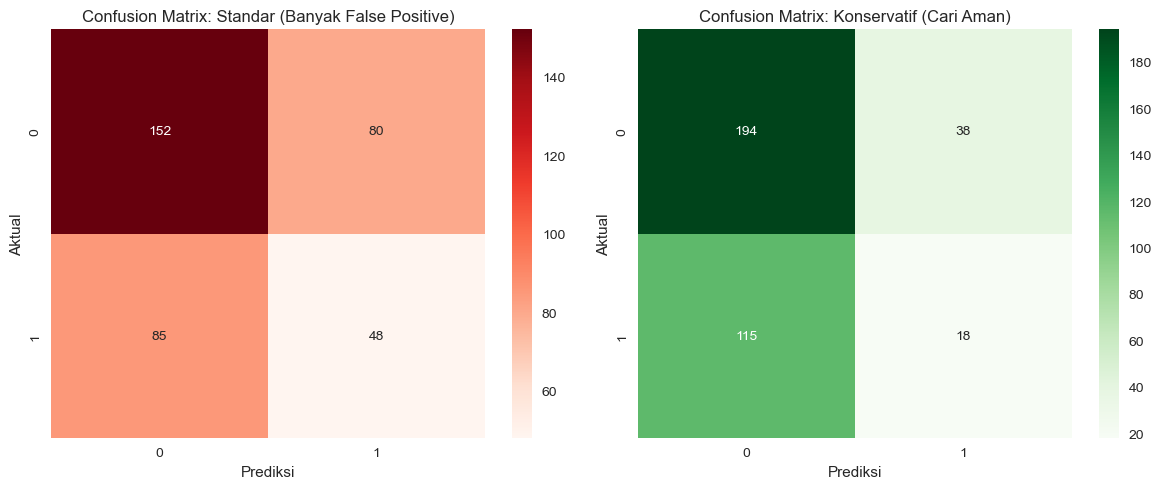

In [5]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred_std), annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix: Standar (Banyak False Positive)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')

plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(y_test, y_pred_safe), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix: Konservatif (Cari Aman)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')

plt.tight_layout()
plt.show()